## Random Forest Assignment
#### Random Forest

Dataset Description:

Use the Glass dataset and apply the Random forest model.

1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.


Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

In [1]:
# Step 1: Exploratory Data Analysis (EDA)
import pandas as pd

# Load the dataset
df = pd.read_excel('glass.xlsx', sheet_name='glass')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

# Get basic information about the dataset
print("\nDataset information:")
print(df.info())

# Get summary statistics of the dataset
print("\nSummary statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values in the dataset:")
print(df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

First 5 rows of the dataset:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: fl

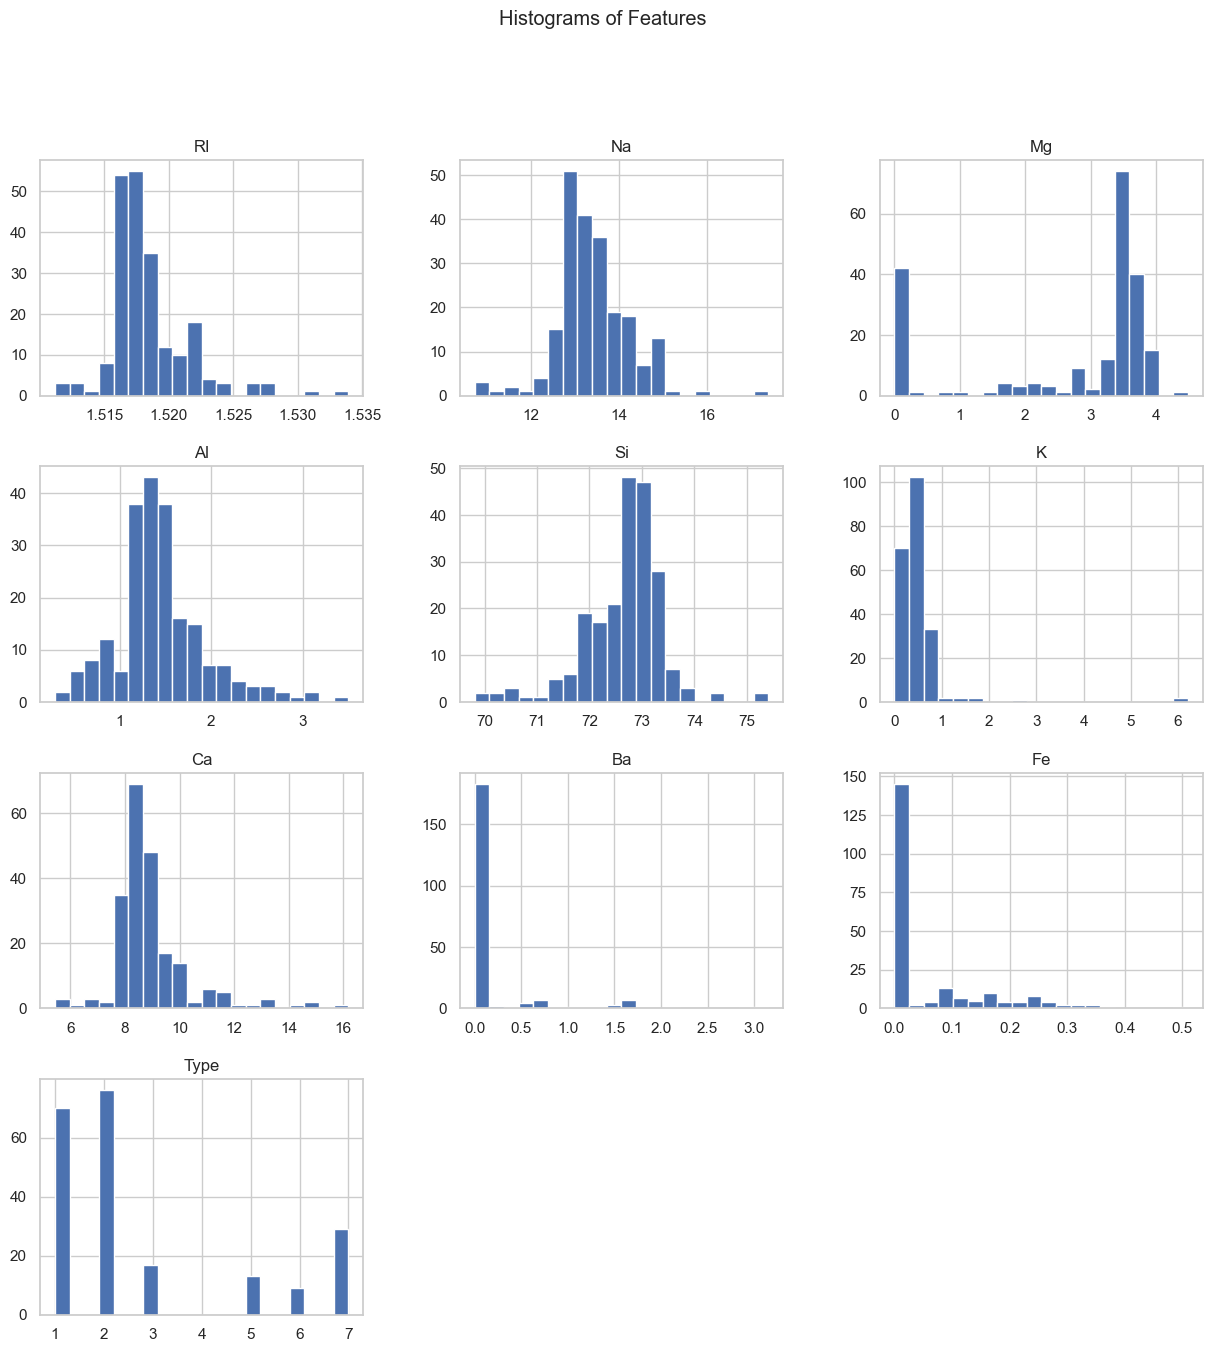

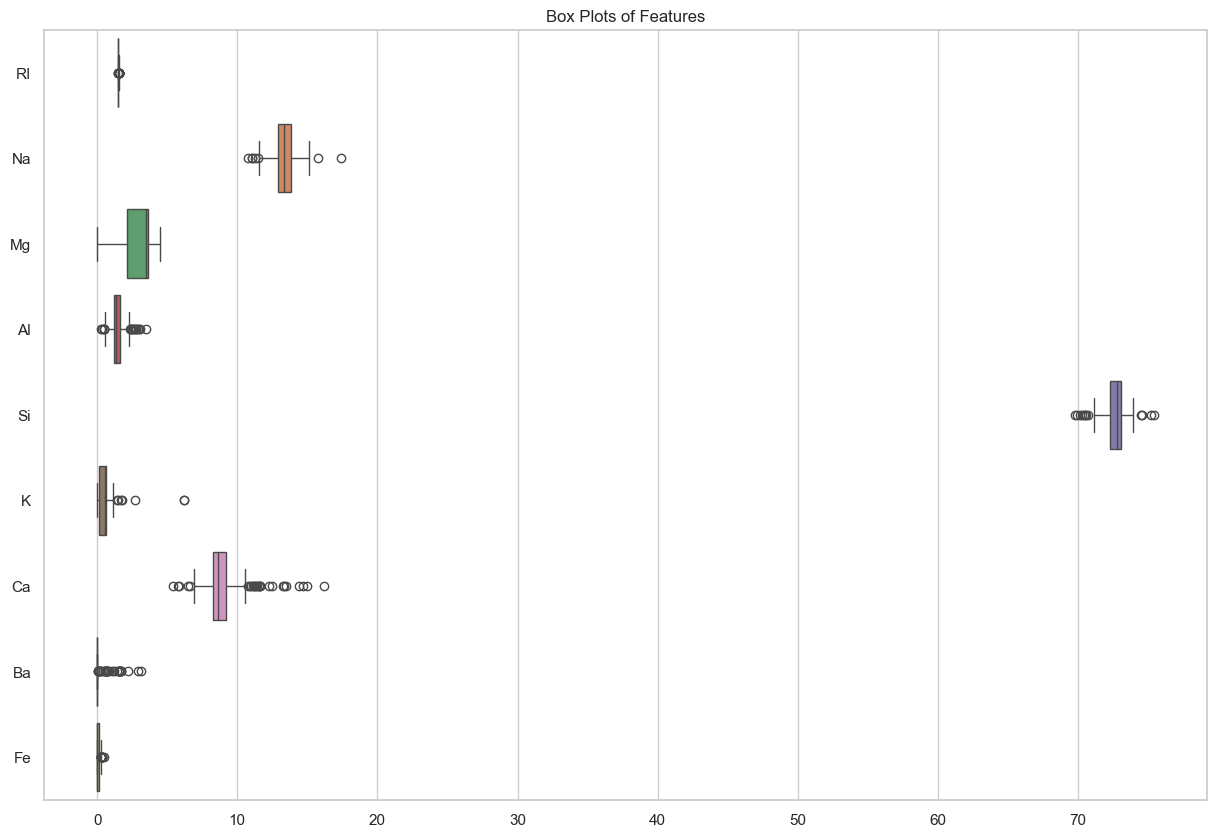

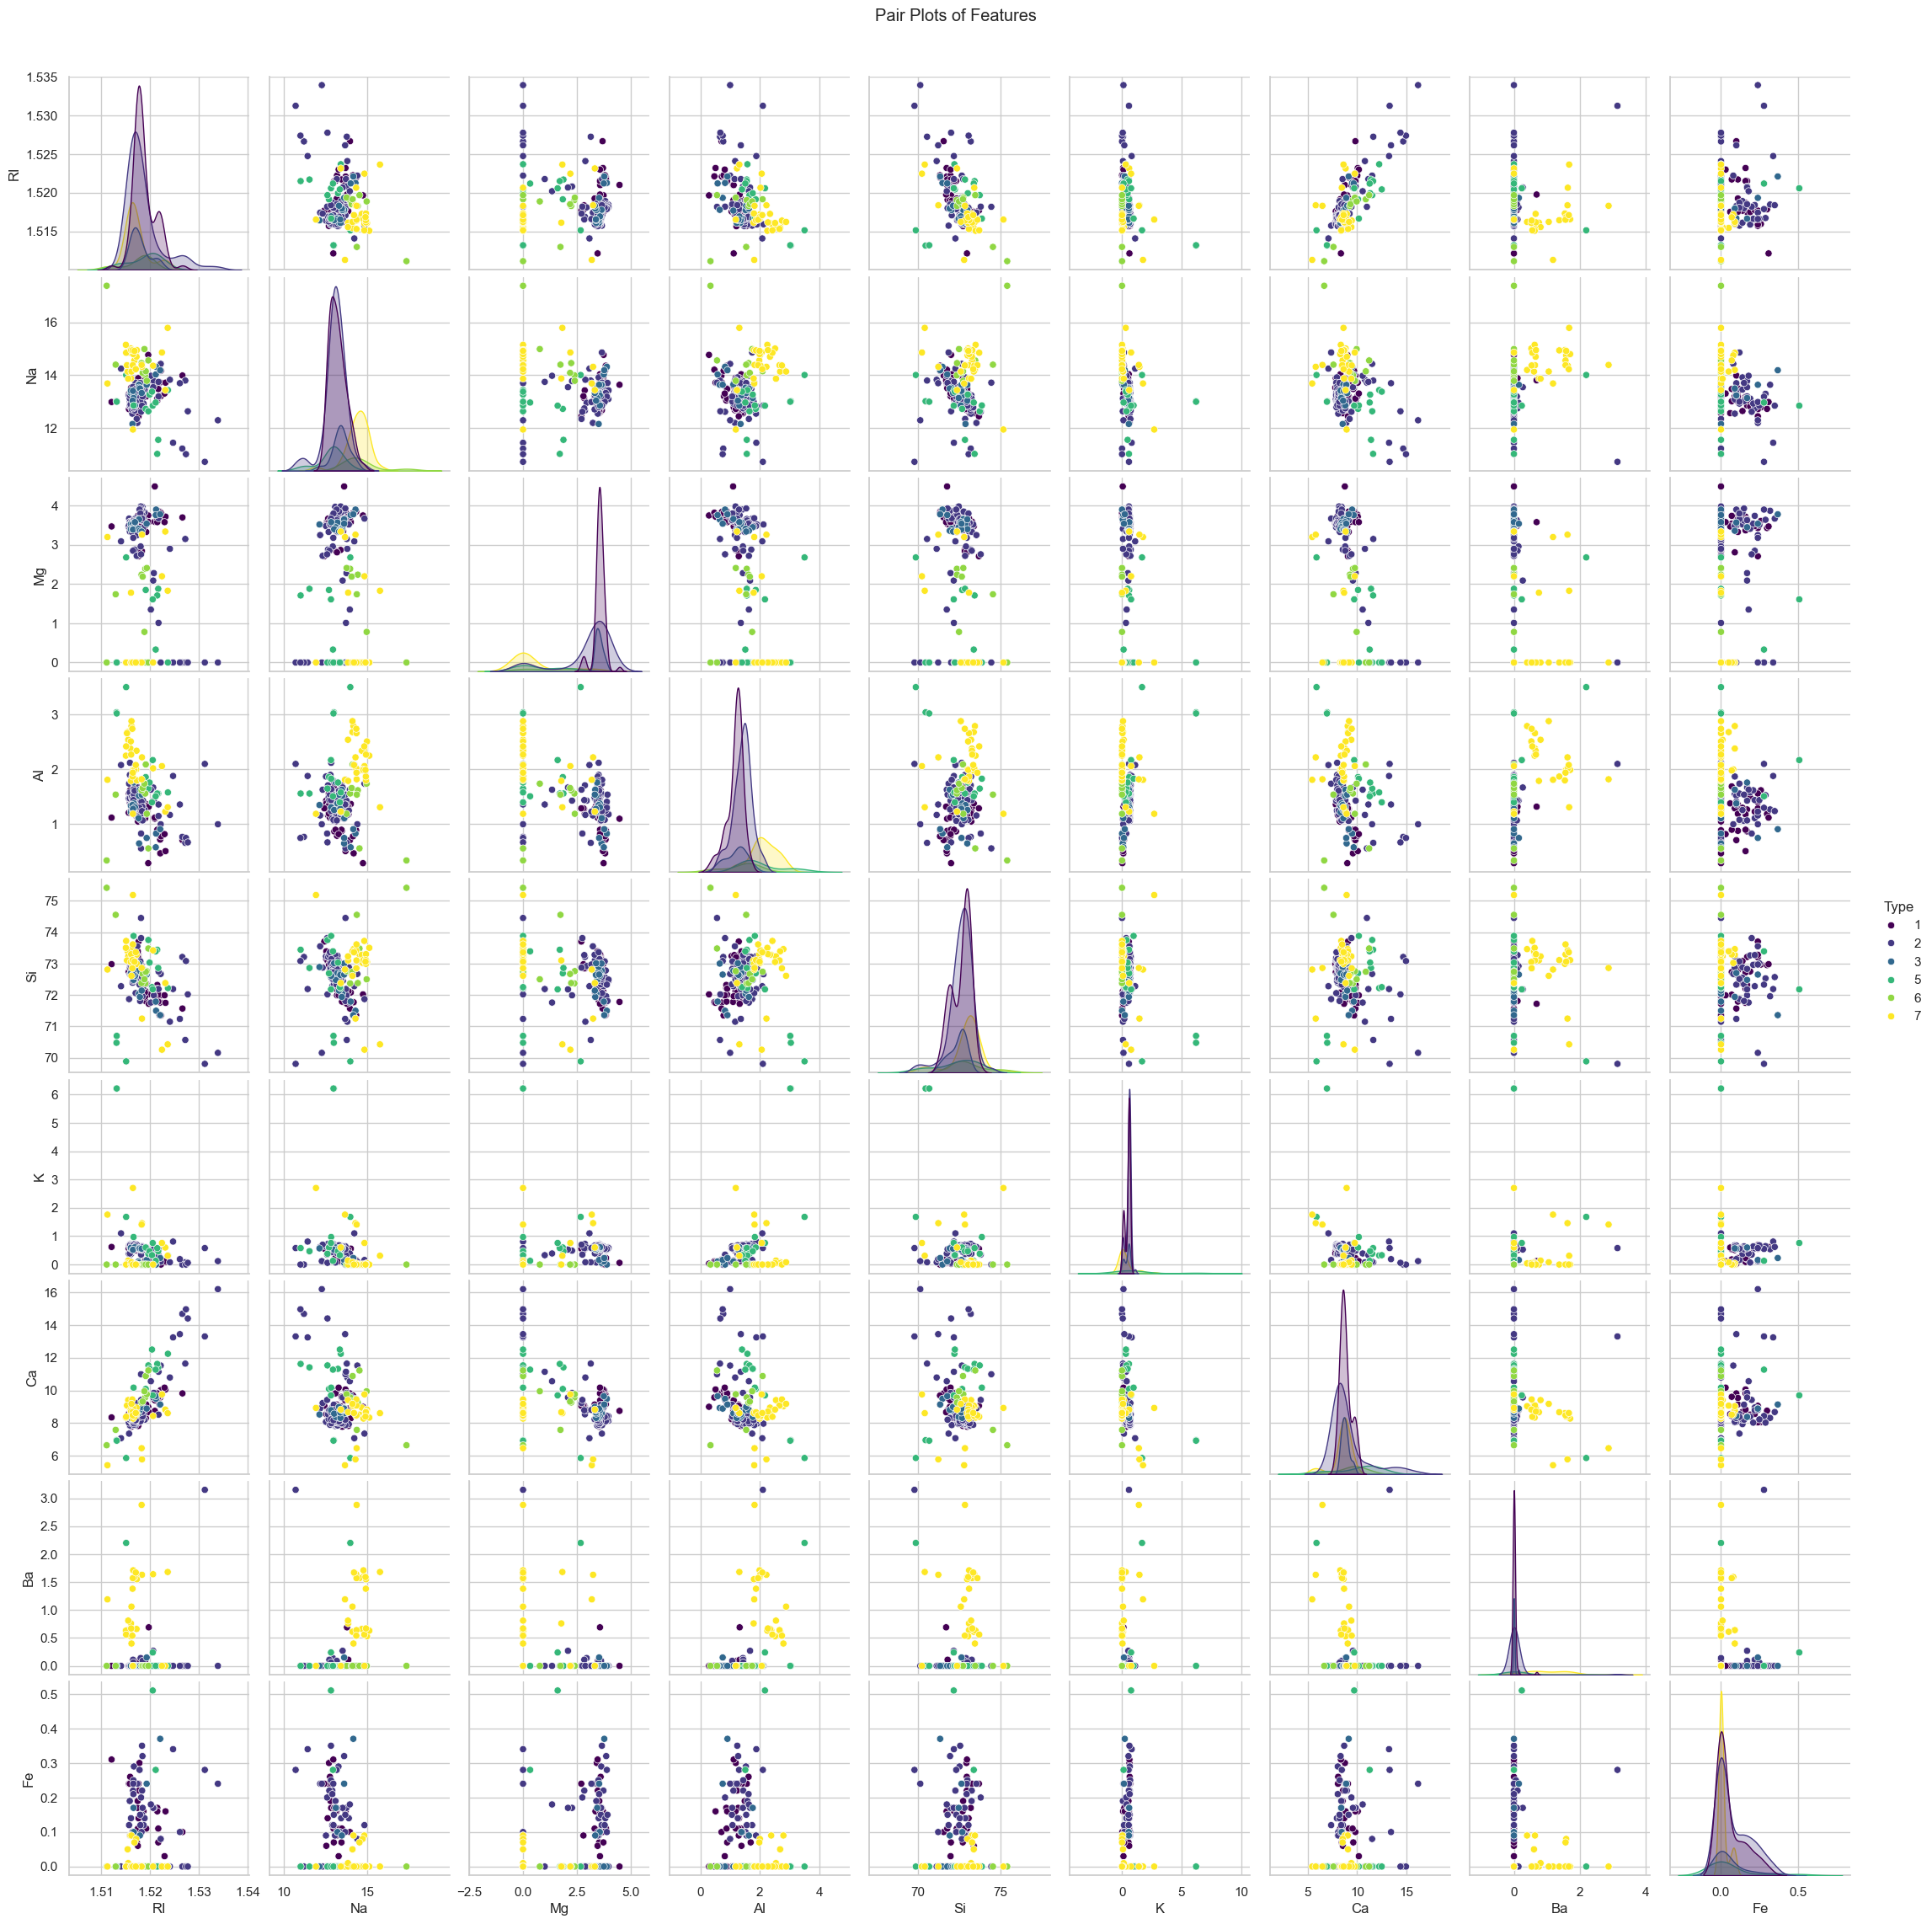

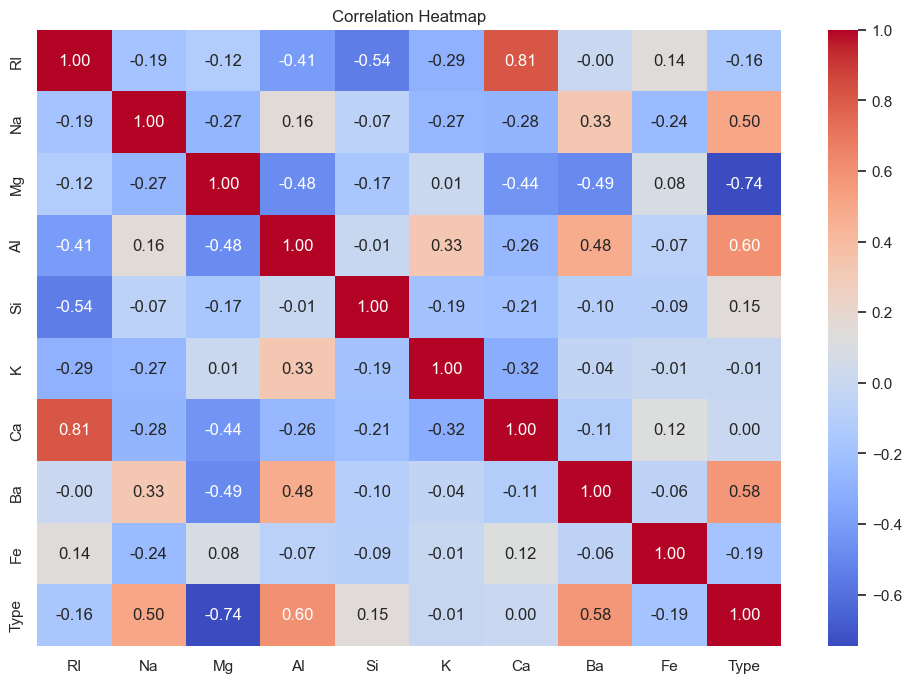

In [2]:
# Step 2: Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
sns.set(style="whitegrid")

# Plot histograms for all features
df.hist(figsize=(15, 15), bins=20)
plt.suptitle("Histograms of Features")
plt.show()

# Plot box plots for all features
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.drop(columns=['Type']), orient="h")
plt.title("Box Plots of Features")
plt.show()

# Plot pair plots to visualize relationships between features
sns.pairplot(df, hue='Type', palette='viridis')
plt.suptitle("Pair Plots of Features", y=1.02)
plt.show()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [3]:
# Step 3: Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check for missing values (already done in Step 1)
# No missing values found, so no imputation is needed.

# Separate features (X) and target variable (y)
X = df.drop(columns=['Type'])
y = df['Type']

# Apply feature scaling (standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled dataset
print("First 5 rows of the scaled dataset:")
print(X_scaled_df.head())

First 5 rows of the scaled dataset:
         RI        Na        Mg        Al        Si         K        Ca  \
0  0.872868  0.284953  1.254639 -0.692442 -1.127082 -0.671705 -0.145766   
1 -0.249333  0.591817  0.636168 -0.170460  0.102319 -0.026213 -0.793734   
2 -0.721318  0.149933  0.601422  0.190912  0.438787 -0.164533 -0.828949   
3 -0.232831 -0.242853  0.698710 -0.310994 -0.052974  0.112107 -0.519052   
4 -0.312045 -0.169205  0.650066 -0.411375  0.555256  0.081369 -0.624699   

         Ba        Fe  
0 -0.352877 -0.586451  
1 -0.352877 -0.586451  
2 -0.352877 -0.586451  
3 -0.352877 -0.586451  
4 -0.352877 -0.586451  


In [4]:
# Step 4: Random Forest Model Implementation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.95      0.84        19
           2       0.79      0.65      0.71        23
           3       0.67      0.50      0.57         4
           5       0.75      0.50      0.60         6
           6       0.75      1.00      0.86         3
           7       0.91      1.00      0.95        10

    accuracy                           0.78        65
   macro avg       0.77      0.77      0.76        65
weighted avg       0.78      0.78      0.77        65


Confusion Matrix:
[[18  1  0  0  0  0]
 [ 4 15  1  1  1  1]
 [ 2  0  2  0  0  0]
 [ 0  3  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0 10]]

Accuracy: 0.78
Precision: 0.78
Recall: 0.78
F1-Score: 0.77


In [5]:
# Step 5: Bagging and Boosting Methods
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

# Bagging (using Decision Trees as base estimators)
bagging_classifier = BaggingClassifier(n_estimators=100, random_state=42)
bagging_classifier.fit(X_train, y_train)
y_pred_bagging = bagging_classifier.predict(X_test)

# Boosting (using AdaBoost)
boosting_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
boosting_classifier.fit(X_train, y_train)
y_pred_boosting = boosting_classifier.predict(X_test)

# Evaluate Bagging
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Bagging Accuracy: {accuracy_bagging:.2f}")

# Evaluate Boosting
accuracy_boosting = accuracy_score(y_test, y_pred_boosting)
print(f"Boosting Accuracy: {accuracy_boosting:.2f}")

Bagging Accuracy: 0.80
Boosting Accuracy: 0.51


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Additional Notes
Bagging and Boosting Methods:

Bagging (Bootstrap Aggregating):

Trains multiple models independently on random subsets of the data (with replacement) and combines their predictions (e.g., by averaging or voting).

Reduces variance and helps avoid overfitting.

Example: Random Forest.

Boosting:

Trains models sequentially, where each model tries to correct the errors of the previous one.

Focuses on reducing bias and improving model accuracy.

Example: AdaBoost, Gradient Boosting.

Handling Imbalanced Data:

Techniques include:

Resampling: Oversampling the minority class or undersampling the majority class.

Synthetic Data Generation: Using techniques like SMOTE (Synthetic Minority Oversampling Technique).

Class Weights: Assigning higher weights to the minority class during model training.